# Abstract

In this report, I assess the early detection of hepatocellular carcinoma using serum α-fetoprotein (AFP) and abdominal ultrasound (US). These data were published by Tong et al. in 2001 [1]. Test performance depends on several features, including prevalence, sensitivity and specificity. Here I focus on patient prevalence and positive predictive value (PPV), which describes the proportion of positive results that are true positives. I examine how low prevalence can lead to a high proportion of false positives among positive results.


# Background

The objective of the published paper [1] was to measure the ability of US and AFP to detect HCC over a seven-year period in 602 patients with chronic viral hepatitis. During the study, HCC was detected in 31 of 602 patients (5.15%). The researchers collected 2552 serum AFP measurements, or 4.2 tests per patient, and performed 1388 US examinations, or 2.3 per patient. They evaluated US and seven AFP concentration thresholds (ng/mL):

1. AFP ≥ 8
2. AFP ≥ 11
3. AFP ≥ 13
4. AFP ≥ 16
5. AFP ≥ 19
6. AFP ≥ 21
7. AFP ≥ 24

The AFP thresholds in Table 4 are concentrations in ng/mL. For the simulations below, I use 31/602 as an illustrative prevalence; it is a cumulative case fraction rather than a point-prevalence measurement.


# Research questions

In this report, I focus on true positive (TP) and false positive (FP) results for HCC detection using AFP and US, in the context of patient prevalence. I examine these relationships through the following questions:

1. What are the TP, FP, true negative (TN), and false negative (FN) values in the simulated data?
2. What are the PPV values in the simulated data?
3. How does population size affect the stability of the simulated PPV?
4. How does PPV change with disease prevalence?
5. How do higher AFP thresholds affect true positives and PPV?


# Hypothesis and potential source of deficiencies

As a main result of the published paper, we can consider the following table [1].
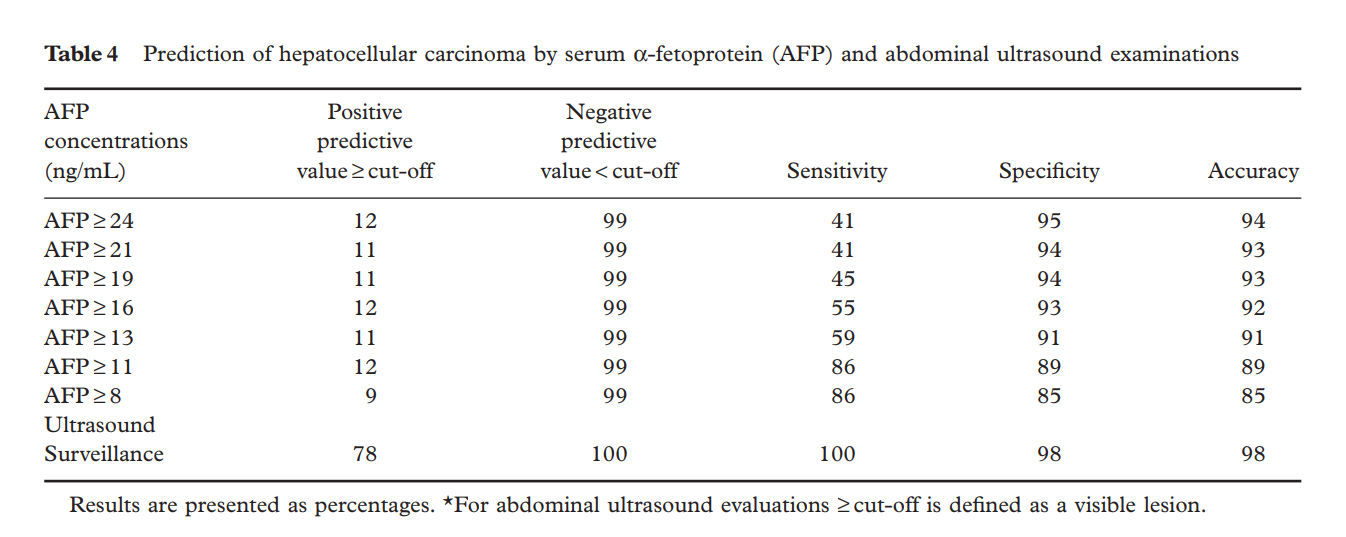
The researchers show us a table where they rate the prediction of HCC with US and different AFP concentration thresholds. With a prevalence as low as 5%, false positives can be problematic: in a population of 100 people with 5 cases, just 5 false positives would give as many false positives as actual cases.

My hypothesis is that false positives will make up a smaller fraction of positive results in larger populations or at higher prevalence. I evaluate this using PPV, the probability of having the disease when a test result is positive.

I use the sensitivity and specificity values to simulate one test per person. This does not reconstruct the original repeated examinations or the PPVs reported in the paper.


# Results and analysis

In [1]:
########################################################################################################################################################
# import libraries
########################################################################################################################################################

from matplotlib import pyplot as plt

import pandas as pd
import numpy as np

# random seed for reproducible results
rng = np.random.default_rng(42)

In [2]:
########################################################################################################################################################
# Generate population with defined prevalence (as True - HCC or False - no HCC)
########################################################################################################################################################

# generator of patient population with defined prevalence
def pop_prev(population: int, prevalence: float):
    if not isinstance(population, (int, np.integer)) or population <= 0:
        raise ValueError('population must be a positive integer')
    if not np.isfinite(prevalence) or not 0 <= prevalence <= 100:
        raise ValueError('prevalence must be between 0 and 100')
    k = round((population / 100) * prevalence)
    j = population - k
    random_list = [False] * int(j) + [True] * int(k)
    random_list2 = np.array(random_list)
    
    return random_list2

# population and prevalence from the published paper
patient_population = 602
prevalence_percent = 100 * 31 / 602

# generate population
pop_real = pop_prev(patient_population, prevalence_percent)
pop_real.sum()

np.int64(31)

Rounding the prevalence to 5% would give 30 positive samples instead of the 31 cases in the study. I use 31/602 here so the simulated population contains exactly 31 cases.


In [3]:
########################################################################################################################################################
# The earlier example by Gavin Chait inspired this analysis; the calculation below has been rewritten.
########################################################################################################################################################

# function for calculating prediction statistics
def get_universal_test_results(sample: np.ndarray, sensitivity: float, specificity: float, verbose=False):
    sample = np.asarray(sample, dtype=bool)
    if sample.ndim != 1 or sample.size == 0:
        raise ValueError('sample must be a non-empty, one-dimensional population')
    if not 0 <= sensitivity <= 1 or not 0 <= specificity <= 1:
        raise ValueError('sensitivity and specificity must be between 0 and 1')

    s = sample.size  # sample size
    ap = int(sample.sum())  # actual positive
    an = s - ap  # actual negative

    # simulate positive test results in the disease and non-disease groups
    tp = int(rng.binomial(ap, sensitivity))
    fp = int(rng.binomial(an, 1 - specificity))
    fn = ap - tp  # false negative
    tn = an - fp  # true negative
    tr = tp + fp  # positive test response
    PPV = 100 * tp / tr if tr else np.nan

    if verbose:
        print('Universal Test Results')
        print('----------------------')
        print(f'{tr:,} positive test results for sample (n = {s:,}), with {ap/s*100:.2f}% sample prevalence.')
        print('----------------------')
        print(f'Actual positive = {ap:,} | Actual negative = {an:,}')
        print(f'True positive   = {tp:,} | True negative   = {tn:,}')
        print(f'False positive  = {fp:,} | False negative  = {fn:,}')
        print('----------------------')
        print(f'Positive predictive value (PPV) = {PPV:.1f}%')
        print(f'Accuracy = {(tp+tn)/s*100:.1f}%')

    return fn, fp, PPV


In [4]:
########################################################################################################################################################
# Testing predictive metrics for abdominal ultrasound examinations
########################################################################################################################################################

# Ultrasound Surveillance sensitivity and specificity - Tab. 4 in paper
sensitivity = 1
specificity = 0.98

# apply function
US =  get_universal_test_results(pop_real, sensitivity, specificity, verbose=True)

Universal Test Results
----------------------
42 positive test results for sample (n = 602), with 5.15% sample prevalence.
----------------------
Actual positive = 31 | Actual negative = 571
True positive   = 31 | True negative   = 560
False positive  = 11 | False negative  = 0
----------------------
Positive predictive value (PPV) = 73.8%
Accuracy = 98.2%


In [5]:
########################################################################################################################################################
# Test prediction metrics for AFP

# Note: Sensitivity and specificity for corresponding AFP threshold levels are ordered left to right. From AFP ≥ 8 (left tail) to AFP ≥ 24 (right tail) 
########################################################################################################################################################

# AFP, different threshold (see note) - Tab. 4 in paper
sensitivity = [0.86, 0.86, 0.59, 0.55, 0.45, 0.41, 0.41]
specificity = [0.85, 0.89, 0.91, 0.93, 0.94, 0.94, 0.95]

# apply function
for threshold, f, b in zip([8, 11, 13, 16, 19, 21, 24], sensitivity, specificity):
    print(f'AFP ≥ {threshold} ng/mL')
    g = get_universal_test_results(pop_real, f, b, verbose=True)

AFP ≥ 8 ng/mL
Universal Test Results
----------------------
126 positive test results for sample (n = 602), with 5.15% sample prevalence.
----------------------
Actual positive = 31 | Actual negative = 571
True positive   = 25 | True negative   = 470
False positive  = 101 | False negative  = 6
----------------------
Positive predictive value (PPV) = 19.8%
Accuracy = 82.2%
AFP ≥ 11 ng/mL
Universal Test Results
----------------------
85 positive test results for sample (n = 602), with 5.15% sample prevalence.
----------------------
Actual positive = 31 | Actual negative = 571
True positive   = 25 | True negative   = 511
False positive  = 60 | False negative  = 6
----------------------
Positive predictive value (PPV) = 29.4%
Accuracy = 89.0%
AFP ≥ 13 ng/mL
Universal Test Results
----------------------
83 positive test results for sample (n = 602), with 5.15% sample prevalence.
----------------------
Actual positive = 31 | Actual negative = 571
True positive   = 19 | True negative   = 507


For US, the simulated PPV is shown above. For AFP, the TP, FP, TN and FN counts differ between thresholds, as do the PPV values. In these simulations, there are many false positives compared with true positives, resulting in relatively low PPV. That is why, in the next analysis, I take a closer look at how FP, FN and PPV change across AFP thresholds.


In [6]:
########################################################################################################################################################
# test FP, FN and PPV for different AFP concentration thresholds

# The function above returns FN, FP and PPV for the following comparisons.
########################################################################################################################################################

afp_thresholds = [8, 11, 13, 16, 19, 21, 24]


In [7]:
########################################################################################################################################################
# calculating FP,FN and PPV for different AFP levels
########################################################################################################################################################

fal_n = []
fal_p = []
PPV = []
for f, b in zip(sensitivity, specificity):
    fn, fp, ppv = get_universal_test_results(pop_real, f, b)
    fal_n.append(fn)
    fal_p.append(fp)
    PPV.append(ppv)

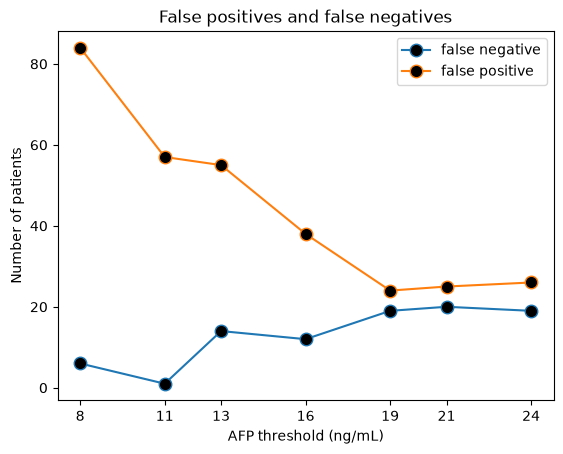

In [8]:
########################################################################################################################################################
# calculating FP (orange) and FN (blue) and for different AFP levels
########################################################################################################################################################

plt.plot(afp_thresholds, fal_n, label = "false negative", marker='o', markersize=9, markerfacecolor = 'black')
plt.plot(afp_thresholds, fal_p, label = "false positive", marker='o', markersize=9, markerfacecolor = 'black')
plt.title('False positives and false negatives')
plt.xlabel('AFP threshold (ng/mL)')
plt.xticks(afp_thresholds)
plt.ylabel('Number of patients')
plt.legend()
plt.show()

As you can see in the figure, false positives generally decrease with an increasing AFP threshold, while false negatives tend to increase. Individual simulated counts vary from run to run.


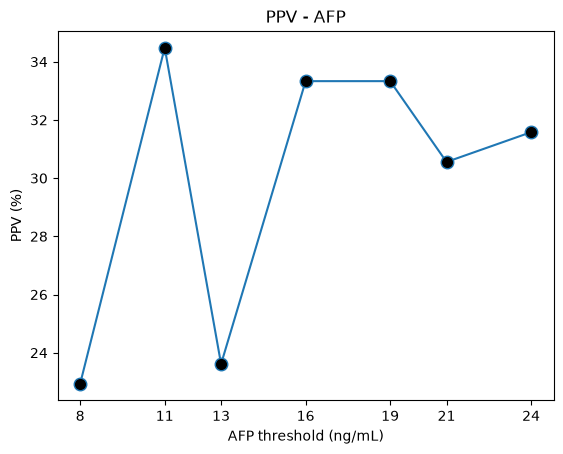

In [9]:
########################################################################################################################################################
# calculating PPV for different AFP levels
########################################################################################################################################################

plt.plot(afp_thresholds, PPV, marker='o', markersize=9, markerfacecolor = 'black')
plt.title('PPV - AFP')
plt.xlabel('AFP threshold (ng/mL)')
plt.xticks(afp_thresholds)
plt.ylabel('PPV (%)')
plt.show()

PPV for AFP is not a monotonic function of the threshold. Both sensitivity and specificity change between thresholds, and the simulated TP and FP values also fluctuate. In the next analysis I examine the effect of population size on the PPV ratio.


### Different population sizes

In [10]:
########################################################################################################################################################
# generating population of 100, 1000, 10000 and 100000 people and prevalence of 5%
########################################################################################################################################################

patient_popul = [100, 1000, 10000, 100000]

pop_list = []
for i in patient_popul:
    pop = pop_prev(i, 5)
    pop_list.append(pop)

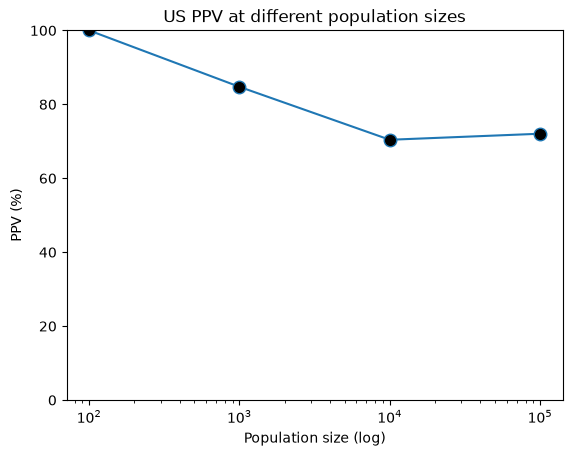

In [11]:
########################################################################################################################################################
# test how PPV change for US for different population size and stable prevalence (5%)
########################################################################################################################################################

# Ultrasound Surveillance - Tab. 4 in paper
sensitivity = 1
specificity = 0.98

# PPV for different sample size
US_pop_PPV = []
for i in pop_list:
        fn, fp, PPV = get_universal_test_results(i, sensitivity, specificity)
        US_pop_PPV.append(PPV)
        
# plot PPV
plt.plot(patient_popul, US_pop_PPV,marker='o', markersize=9, markerfacecolor = 'black')
plt.title('US PPV at different population sizes')
plt.xlabel('Population size (log)')
plt.ylabel('PPV (%)')
plt.xscale('log')
plt.ylim([0, 100])
plt.show()

At fixed prevalence, sensitivity and specificity, the underlying US PPV does not depend on population size. The simulated values fluctuate around it. This single run is not enough to decide whether the original sample of 602 people was sufficient for a particular level of precision.


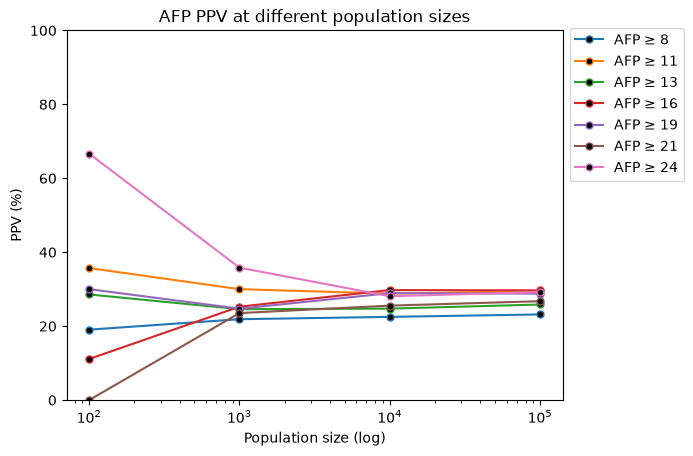

In [12]:
########################################################################################################################################################
# test how PPV change for AFP for different population size and stable prevalence (5%)
########################################################################################################################################################

# AFP, diff threshold - - Tab. 4 in paper
sensitivity = [0.86, 0.86, 0.59, 0.55, 0.45, 0.41, 0.41]
specificity = [0.85, 0.89, 0.91, 0.93, 0.94, 0.94, 0.95]

# PPV for different sample size
AFP_pop_PPV = []
for f, b in zip(sensitivity, specificity):
    for i in pop_list:
        fn, fp, PPV = get_universal_test_results(i, f, b)
        AFP_pop_PPV.append(PPV)

# split test to 4 (we test 4 population sizes)
split_set_pop = list()
set_size_pop = 4

for i in range(0, len(AFP_pop_PPV), set_size_pop):
    split_set_pop.append(AFP_pop_PPV[i:i+set_size_pop])
    
# plot PPV for AFP
for i in split_set_pop:
    plt.plot(patient_popul, i,marker='o', markersize=5, markerfacecolor = 'black')
    plt.title('AFP PPV at different population sizes')
    plt.xlabel('Population size (log)')
    plt.ylabel('PPV (%)')
    plt.xscale('log')
    plt.ylim([0, 100])
    plt.legend(['AFP ≥ 8', 'AFP ≥ 11', 'AFP ≥ 13','AFP ≥ 16','AFP ≥ 19', 'AFP ≥ 21','AFP ≥ 24'], loc='center left', bbox_to_anchor=(1, 0.8))
plt.show()


Increasing population size does not change the underlying PPV when prevalence, sensitivity and specificity stay fixed. Larger populations reduce sampling variation, although a single simulation at each size does not measure that variation reliably.


Testing different prevalence levels is another analysis that can help me understand how PPV changes across AFP thresholds.


### Different prevalence

In [13]:
########################################################################################################################################################
# test effect of different prevalence with sample size of 602 people
########################################################################################################################################################

# I analyzed prevalence of 0.1, 1, 5, 10, 25 and 50 %
prevalence = [0.1, 1, 5, 10, 25, 50]

# data generating
popul = []
for i in prevalence:
        ss = pop_prev(patient_population, i)
        popul.append(ss)
# realized prevalence after rounding to whole patients
realized_prevalence = [100 * samples.mean() for samples in popul]
pd.DataFrame({'requested prevalence (%)': prevalence, 'realized prevalence (%)': realized_prevalence})


,requested prevalence (%),realized prevalence (%)
0,0.1,0.166113
1,1.0,0.996678
2,5.0,4.983389
3,10.0,9.966777
4,25.0,24.916944
5,50.0,50.000000


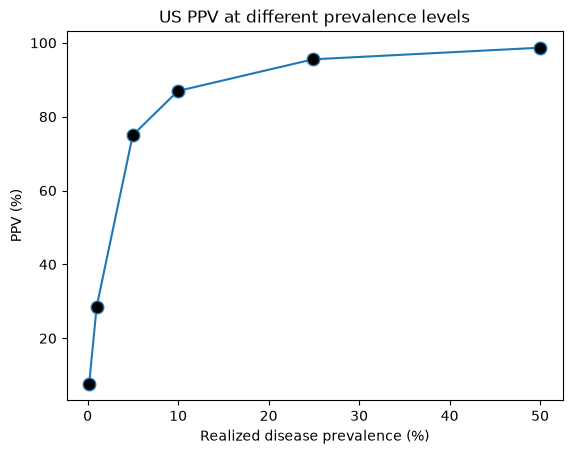

In [14]:
########################################################################################################################################################
# test effect of different prevalence with sample size of 602 people to PPV US
########################################################################################################################################################

# Ultrasound Surveillance - Tab. 4 in paper
sensitivity = 1
specificity = 0.98

# data generating
PPV_US = []
for i in popul:
    fn, fp, PPV =  get_universal_test_results(i, sensitivity, specificity)
    PPV_US.append(PPV)
    
# plot PPV for different prevalence
plt.plot(realized_prevalence, PPV_US, marker='o', markersize=9, markerfacecolor = 'black')
plt.title('US PPV at different prevalence levels')
plt.xlabel('Realized disease prevalence (%)')
plt.ylabel('PPV (%)')
plt.show()

Increasing disease prevalence increases the underlying PPV for US when sensitivity and specificity are fixed. The relationship follows Bayes' rule; the shape of this simulated curve does not establish an optimal prevalence cutoff.


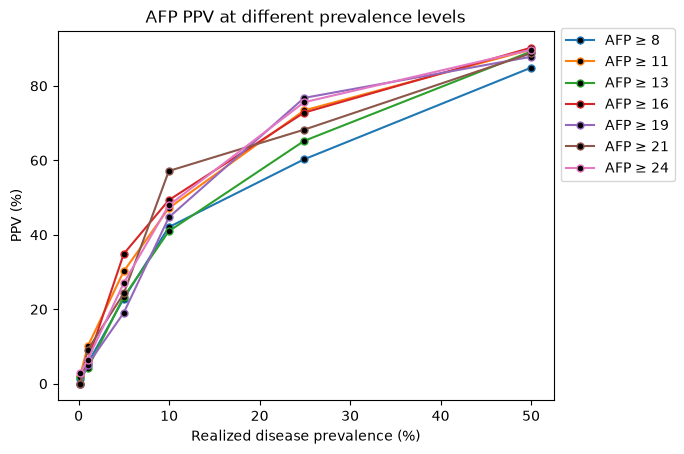

In [15]:
########################################################################################################################################################
# test effect of different prevalence with sample size of 602 people to PPV AFP
########################################################################################################################################################

# AFP, diff threshold  - Tab. 4 in paper
sensitivity = [0.86, 0.86, 0.59, 0.55, 0.45, 0.41, 0.41]
specificity = [0.85, 0.89, 0.91, 0.93, 0.94, 0.94, 0.95]

# data generating
PPV_AFP = []
for f, b in zip(sensitivity, specificity):
    for i in popul:
        fn, fp, PPV = get_universal_test_results(i, f, b)
        PPV_AFP.append(PPV)
        
# I analyze 6 different prevalence so split set according to this
split_set_pop2 = list()
set_size_pop2 = 6

for i in range(0, len(PPV_AFP), set_size_pop2):
    split_set_pop2.append(PPV_AFP[i:i+set_size_pop2])
    

    
for x in split_set_pop2:
    plt.plot(realized_prevalence, x, marker='o', markersize=5, markerfacecolor = 'black')
    plt.title('AFP PPV at different prevalence levels')
    plt.xlabel('Realized disease prevalence (%)')
    plt.ylabel('PPV (%)')
    plt.legend(['AFP ≥ 8', 'AFP ≥ 11', 'AFP ≥ 13','AFP ≥ 16','AFP ≥ 19', 'AFP ≥ 21','AFP ≥ 24'], loc='center left', bbox_to_anchor=(1, 0.8))
plt.show()


As with US, the underlying AFP PPV increases with disease prevalence when sensitivity and specificity are fixed.


In [16]:
########################################################################################################################################################
# Table representation of PPV AFP
########################################################################################################################################################

df10 = pd.DataFrame(
    split_set_pop2,
    index=[f'AFP ≥ {threshold}' for threshold in afp_thresholds],
    columns=[f'{value:.2f}%' for value in realized_prevalence],
).T
df10.index.name = 'Realized prevalence'
df10.style.set_uuid('ppv').format('{:.1f}').set_caption('Simulated PPV (%)').highlight_max(color='lightgreen', axis=1)


,AFP ≥ 8,AFP ≥ 11,AFP ≥ 13,AFP ≥ 16,AFP ≥ 19,AFP ≥ 21,AFP ≥ 24
Realized prevalence,,,,,,,
0.17%,1.1,2.1,1.8,0.0,0.0,0.0,2.8
1.00%,5.4,10.0,4.1,6.1,5.1,9.1,6.5
4.98%,22.9,30.2,23.3,34.9,19.0,24.2,27.0
9.97%,42.1,47.2,41.0,49.3,44.7,57.1,47.9
24.92%,60.3,73.4,65.2,72.8,76.8,68.2,75.6
50.00%,84.9,89.8,89.2,90.3,87.8,88.7,89.7


In the table, green cells represent the largest simulated PPV for each prevalence level. These rankings can vary between runs. Comparing expected PPV from sensitivity and specificity would separate the underlying threshold differences from this sampling variation.


# Conclusion

In the presented analysis, I focused on the potential problem of high FP ratios for HCC prediction by US and different AFP levels. Increasing population size does not improve the underlying PPV, but it reduces sampling variation. Across the AFP thresholds, higher specificity reduces expected false positives while lower sensitivity increases expected false negatives.

For both US and AFP, PPV increases with disease prevalence when test performance is fixed. A single simulated population cannot reliably establish which threshold gives the highest PPV, and PPV alone does not determine the best screening strategy. The analysis illustrates these statistical relationships; it does not reconstruct the original study or establish a 10% prevalence cutoff.


# Methods

The information in this report comes from the study by Tong et al. (2001) [1].

In the report, I evaluate the following prediction metrics:

- True positives (TP) are actual positives correctly classified as positive [2].
- False positives (FP) are actual negatives incorrectly classified as positive [3].
- True negatives (TN) are actual negatives correctly classified as negative [2].
- False negatives (FN) are actual positives incorrectly classified as negative [2].
- Positive predictive value (PPV) is the proportion of predicted positives that are actual positives [4]:

$$PPV = \frac{TP}{TP + FP}.$$

Prevalence is the proportion of the population that has the target condition [5]:

$$\mathrm{prevalence} = \frac{\mathrm{number\ with\ disease}}{\mathrm{total\ population}}.$$

I express both prevalence and PPV as percentages in the tables and figures. The false-positive rate, $FP/(FP+TN)$, has a different denominator from the proportion of positive results that are false, $FP/(TP+FP)$.

For a fixed prevalence $p$, sensitivity $Se$ and specificity $Sp$, the underlying PPV is:

$$PPV = \frac{pSe}{pSe + (1-p)(1-Sp)}.$$

Population size cancels from this expression. I use independent binomial draws to simulate TP and FP counts, treating sensitivity and specificity as fixed. PPV is undefined when there are no positive results, so the code returns `NaN` in that case.

In the report I use pandas and NumPy for calculations and Matplotlib for visualizations. The code is written in a Jupyter notebook.


## REF

1. TONG, Myron J.; BLATT, Lawrence M.; KAO, Vincent WC. Surveillance for hepatocellular carcinoma in patients with chronic viral hepatitis in the United States of America. Journal of gastroenterology and hepatology, 2001, 16.5: 553-559. https://doi.org/10.1046/j.1440-1746.2001.02470.x
2. Wang, H., Zheng, H. (2013). True Positive Rate. In: Dubitzky, W., Wolkenhauer, O., Cho, KH., Yokota, H. (eds) Encyclopedia of Systems Biology. Springer, New York, NY. https://doi.org/10.1007/978-1-4419-9863-7_255
3. Wang, H., Zheng, H. (2013). False Positive Rate. In: Dubitzky, W., Wolkenhauer, O., Cho, KH., Yokota, H. (eds) Encyclopedia of Systems Biology. Springer, New York, NY. https://doi.org/10.1007/978-1-4419-9863-7_224
4. Wang, H., Zheng, H. (2013). Positive Predictive Value. In: Dubitzky, W., Wolkenhauer, O., Cho, KH., Yokota, H. (eds) Encyclopedia of Systems Biology. Springer, New York, NY. https://doi.org/10.1007/978-1-4419-9863-7_256
5. WHITING, Penny F., et al. How well do health professionals interpret diagnostic information? A systematic review. BMJ open, 2015, 5.7: e008155.